<a href="https://colab.research.google.com/github/wezc0m/CIC-IDS-2018-Random-Forest/blob/hasil-3/CIC_IDS_2018_RF_with_SMOTE_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [1]:
# NumPy
# Digunakan untuk operasi numerik dan pengolahan array
import numpy as np

# Pandas
# Digunakan untuk membaca, mengolah, dan menganalisis dataset
import pandas as pd

# Matplotlib
# Digunakan untuk membuat visualisasi data
import matplotlib.pyplot as plt

# Seaborn
# Digunakan untuk membuat visualisasi statistik
import seaborn as sns

# Scikit-learn
# Digunakan untuk membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split

# Scikit-learn
# Digunakan untuk mengevaluasi performa model klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Random Forest
# Digunakan untuk membuat dan melatih model Machine Learning untuk klasifikasi traffic jaringan
from sklearn.ensemble import RandomForestClassifier

# Imbalanced-learn
# Digunakan untuk menangani ketidakseimbangan jumlah kelas pada dataset menggunakan metode SMOTE
from imblearn.over_sampling import SMOTE

## 2. Load Dataset

In [2]:
# Membaca dataset CIC-IDS2018 dari file CSV
df = pd.read_csv("/content/cic.csv")

# Menampilkan 5 baris pertama dataset
print(df.head())

# Menampilkan ukuran dataset
# Hasil: (jumlah baris, 80 kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan jumlah kolom
print("Jumlah kolom:", len(df.columns))

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

## 3. Cleaning Dataset

# a. Melihat Informasi Dataset

In [3]:
# Digunakan untuk melihat jumlah data, nama kolom, dan tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

# b. Mengecek missing value

In [4]:
# Digunakan untuk mengetahui apakah terdapat nilai kosong pada setiap kolom
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64


# c. Menghapus data duplikat

In [5]:
# Data yang sama tidak diperlukan untuk proses training
df = df.drop_duplicates()

print("\nUkuran dataset setelah menghapus duplikat:")
print(df.shape)


Ukuran dataset setelah menghapus duplikat:
(822947, 80)


# d. Mengecek nilai tak hingga

In [6]:
print("\nJumlah nilai Infinity:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


Jumlah nilai Infinity:
5365


# e. Mengganti nilai Infinity menjadi NaN


In [7]:
df = df.replace([np.inf, -np.inf], np.nan)

# f. Mengecek kembali missing value


In [8]:
# Setelah nilai Infinity diubah menjadi NaN
print("\nMissing Value setelah pengecekan Infinity:")
print(df.isnull().sum().sum())


Missing Value setelah pengecekan Infinity:
7642


# g. Hapus missing value

In [9]:
# Dilakukan setelah Infinity diubah menjadi NaN
df = df.dropna()

print("\nUkuran dataset setelah membersihkan missing value:")
print(df.shape)


Ukuran dataset setelah membersihkan missing value:
(819126, 80)


# h. Mengecek kembali kondisi dataset


In [10]:
# untuk memastikan dataset sudah bersih
print("\nInformasi dataset setelah cleaning:")
df.info()


Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 819126 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           819126 non-null  int64  
 1   Protocol           819126 non-null  int64  
 2   Timestamp          819126 non-null  object 
 3   Flow Duration      819126 non-null  int64  
 4   Tot Fwd Pkts       819126 non-null  int64  
 5   Tot Bwd Pkts       819126 non-null  int64  
 6   TotLen Fwd Pkts    819126 non-null  int64  
 7   TotLen Bwd Pkts    819126 non-null  int64  
 8   Fwd Pkt Len Max    819126 non-null  int64  
 9   Fwd Pkt Len Min    819126 non-null  int64  
 10  Fwd Pkt Len Mean   819126 non-null  float64
 11  Fwd Pkt Len Std    819126 non-null  float64
 12  Bwd Pkt Len Max    819126 non-null  int64  
 13  Bwd Pkt Len Min    819126 non-null  int64  
 14  Bwd Pkt Len Mean   819126 non-null  float64
 15  Bwd Pkt Len Std   

## 3. Eksplorasi Data (EDA)

# a. Melihat ukuran dataset

In [11]:
# Mengetahui jumlah baris dan kolom dataset
print("Jumlah Baris  :", df.shape[0])
print("Jumlah Kolom  :", df.shape[1])

Jumlah Baris  : 819126
Jumlah Kolom  : 80


# b. Melihat statistik deskriptif

In [12]:
# Melihat statistik dasar dari fitur numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Dst Port,819126.0,6.003352e+03,1.579974e+04,0.000000e+00,53.0,80.0,445.00,6.553300e+04
Protocol,819126.0,8.697304e+00,4.886142e+00,0.000000e+00,6.0,6.0,17.00,1.700000e+01
Flow Duration,819126.0,8.007824e+06,1.425916e+09,-9.190110e+11,317.0,49564.5,1755661.75,1.200000e+08
Tot Fwd Pkts,819126.0,7.658836e+00,5.022804e+01,1.000000e+00,1.0,2.0,9.00,5.115000e+03
Tot Bwd Pkts,819126.0,8.957209e+00,1.185914e+02,0.000000e+00,1.0,1.0,7.00,9.198000e+03
...,...,...,...,...,...,...,...,...
Active Min,819126.0,5.114668e+04,6.334491e+05,0.000000e+00,0.0,0.0,0.00,1.102401e+08
Idle Mean,819126.0,3.969899e+06,6.126370e+08,0.000000e+00,0.0,0.0,0.00,3.394503e+11
Idle Std,819126.0,9.341273e+05,4.322063e+08,0.000000e+00,0.0,0.0,0.00,2.432682e+11
Idle Max,819126.0,6.160411e+06,1.722154e+09,0.000000e+00,0.0,0.0,0.00,9.797810e+11


# c. Melihat distribusi label

In [13]:
# Mengetahui jumlah data pada setiap kelas
print("Distribusi Label:")
print(df['Label'].value_counts())

Distribusi Label:
Label
Benign            662458
SSH-Bruteforce    117322
FTP-BruteForce     39346
Name: count, dtype: int64


# d. Melihat persentase distribusi label

In [14]:
# Menghitung persentase setiap kelas
print("Persentase Label:")
print(df['Label'].value_counts(normalize=True) * 100)

Persentase Label:
Label
Benign            80.873761
SSH-Bruteforce    14.322827
FTP-BruteForce     4.803412
Name: proportion, dtype: float64


# e. Visualisasi distribusi label

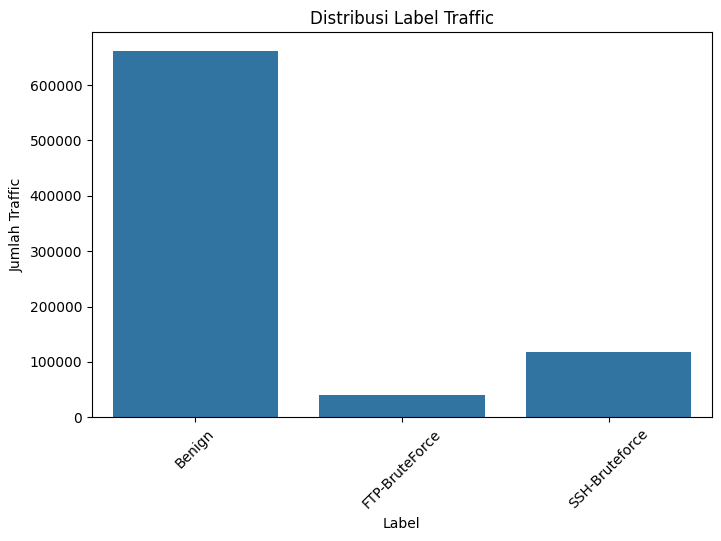

In [15]:
# Visualisasi jumlah traffic berdasarkan label
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Label')

plt.title('Distribusi Label Traffic')
plt.xlabel('Label')
plt.ylabel('Jumlah Traffic')
plt.xticks(rotation=45)
plt.show()

# f. Melihat fitur numerik

In [16]:
# Mengidentifikasi fitur dengan tipe data numerik
numeric_columns = df.select_dtypes(include=np.number).columns

print("Jumlah fitur numerik:", len(numeric_columns))
print("Fitur numerik:")
print(numeric_columns.tolist())

Jumlah fitur numerik: 78
Fitur numerik:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 

# g. Melihat distribusi fitur

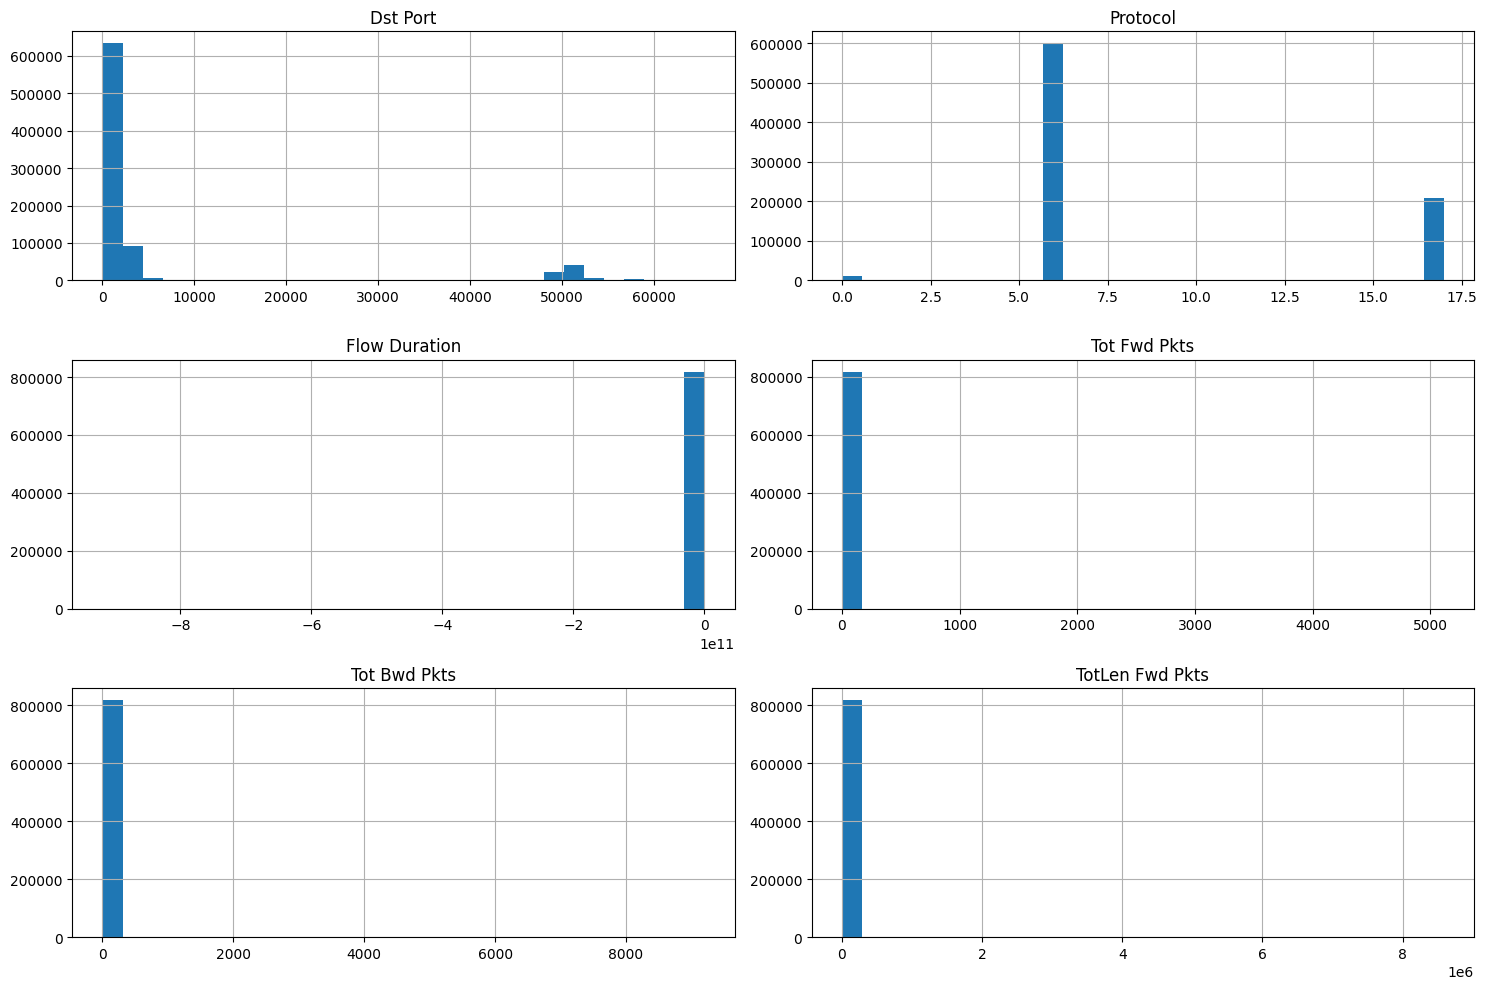

In [17]:
# Melihat distribusi beberapa fitur numerik
features_to_plot = numeric_columns[:6]

df[features_to_plot].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

# h. Melihat korelasi antar fitur

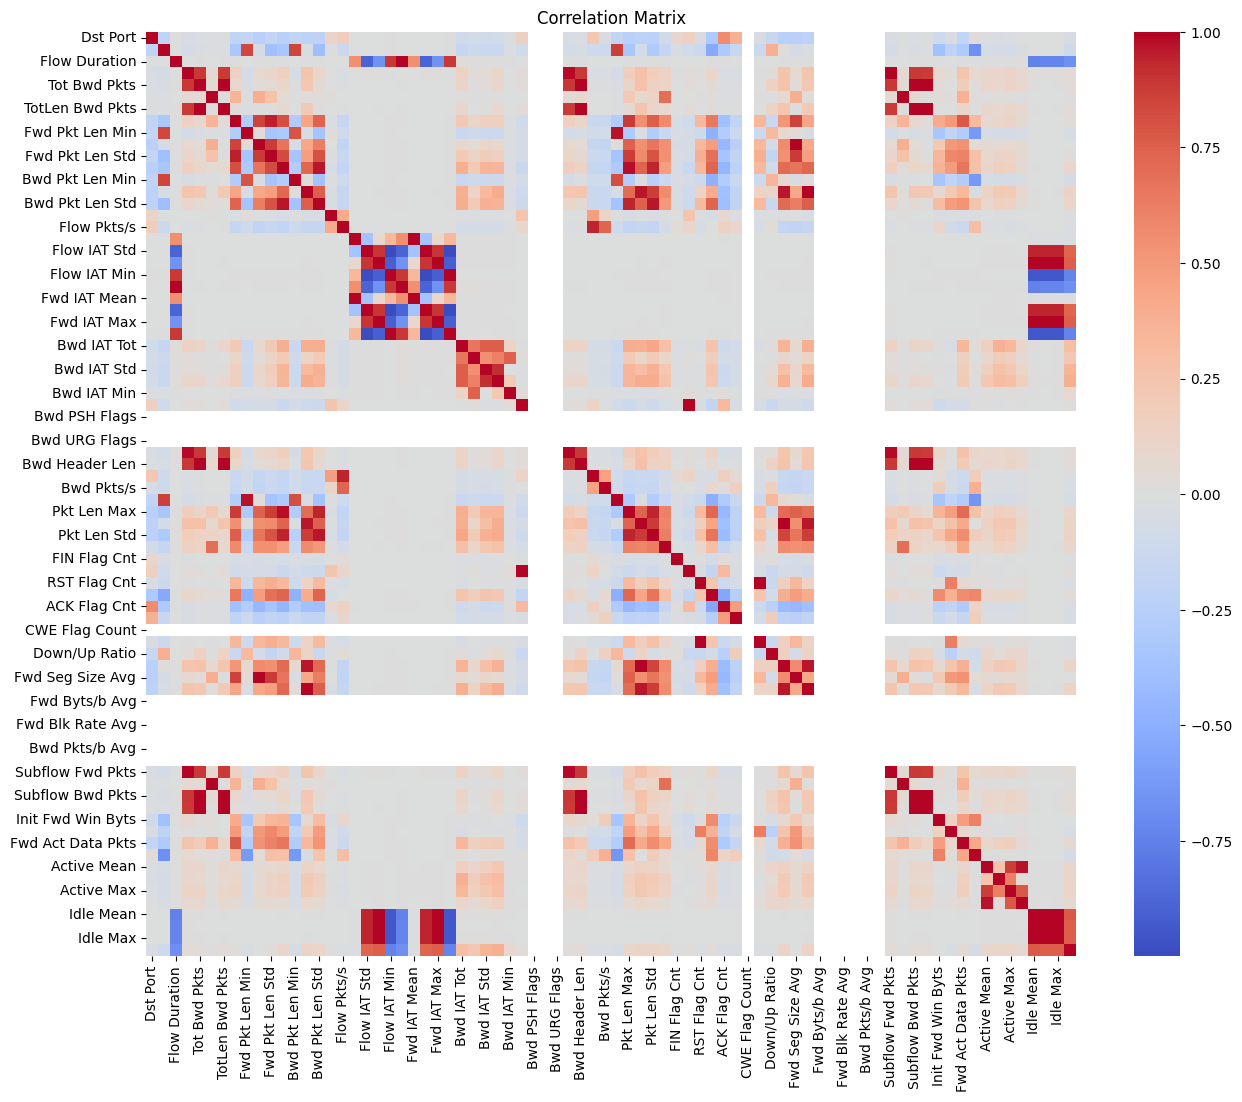

In [18]:
# Menghitung korelasi antar fitur numerik
correlation = df[numeric_columns].corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

# i. Membandingkan fitur berdasarkan label

In [19]:
# Membandingkan nilai rata-rata fitur berdasarkan label
df.groupby('Label')[numeric_columns].mean().T

Label,Benign,FTP-BruteForce,SSH-Bruteforce
Dst Port,7.417971e+03,21.000000,21.999940
Protocol,9.335203e+00,6.000000,6.000000
Flow Duration,9.849716e+06,10.300869,293158.461627
Tot Fwd Pkts,6.196991e+00,1.000000,18.146298
Tot Bwd Pkts,7.963930e+00,1.000000,17.234346
...,...,...,...
Active Min,6.324262e+04,0.000000,0.000000
Idle Mean,4.908760e+06,0.000000,0.000000
Idle Std,1.155044e+06,0.000000,0.000000
Idle Max,7.617317e+06,0.000000,0.000000


# j. Visualisasi fitur berdasarkan label

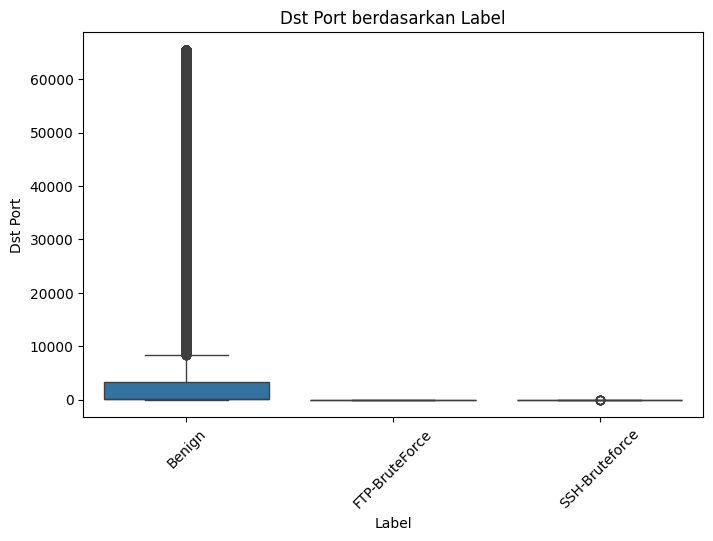

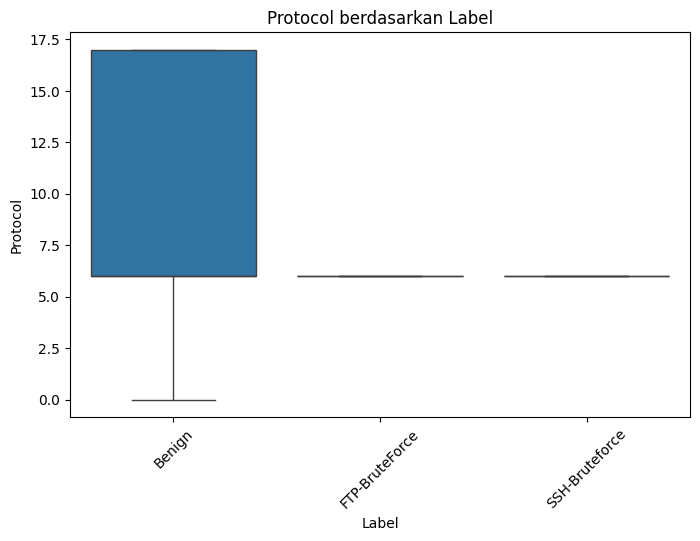

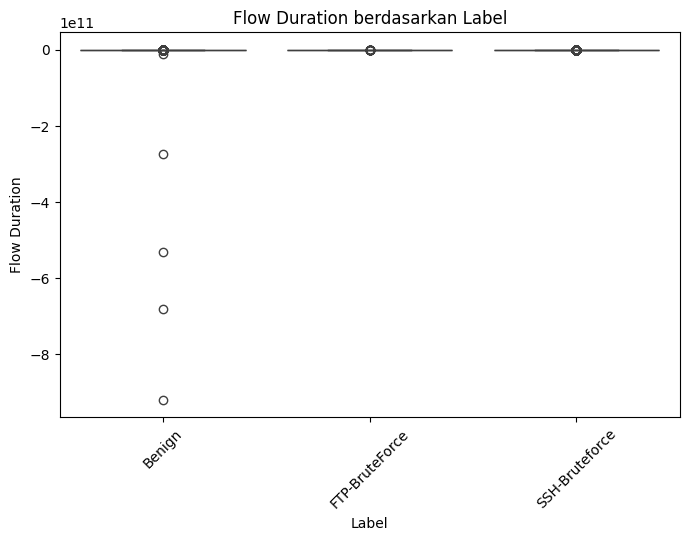

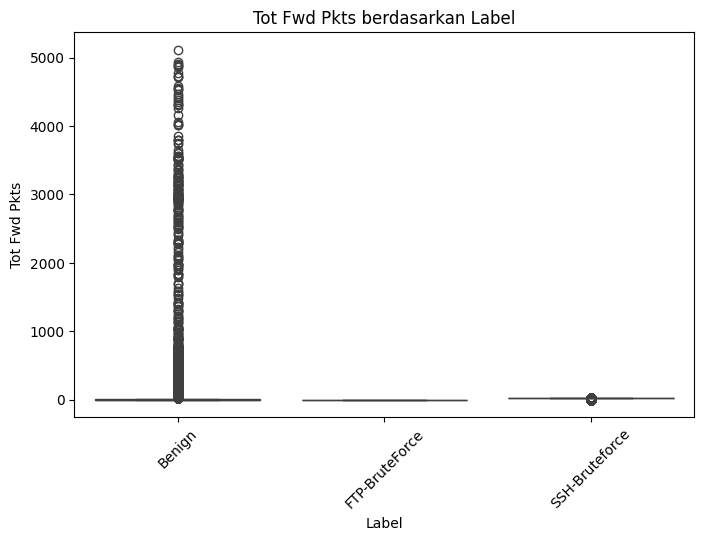

In [20]:
# Membandingkan distribusi fitur antara setiap kelas
features_to_compare = numeric_columns[:4]

for feature in features_to_compare:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='Label',
        y=feature
    )

    plt.title(f'{feature} berdasarkan Label')
    plt.xlabel('Label')
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.show()

# k. Mengecek outlier

In [21]:
# Mengecek jumlah outlier menggunakan metode IQR
for feature in numeric_columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()

    print(f"{feature}: {outliers} outlier")

Dst Port: 186150 outlier
Protocol: 0 outlier
Flow Duration: 152159 outlier
Tot Fwd Pkts: 100887 outlier
Tot Bwd Pkts: 123326 outlier
TotLen Fwd Pkts: 7112 outlier
TotLen Bwd Pkts: 49418 outlier
Fwd Pkt Len Max: 224 outlier
Fwd Pkt Len Min: 12870 outlier
Fwd Pkt Len Mean: 8454 outlier
Fwd Pkt Len Std: 6408 outlier
Bwd Pkt Len Max: 0 outlier
Bwd Pkt Len Min: 201028 outlier
Bwd Pkt Len Mean: 50224 outlier
Bwd Pkt Len Std: 23639 outlier
Flow Byts/s: 190091 outlier
Flow Pkts/s: 151308 outlier
Flow IAT Mean: 146869 outlier
Flow IAT Std: 126470 outlier
Flow IAT Max: 149788 outlier
Flow IAT Min: 152917 outlier
Fwd IAT Tot: 138883 outlier
Fwd IAT Mean: 128067 outlier
Fwd IAT Std: 178902 outlier
Fwd IAT Max: 133271 outlier
Fwd IAT Min: 133898 outlier
Bwd IAT Tot: 184915 outlier
Bwd IAT Mean: 194931 outlier
Bwd IAT Std: 177457 outlier
Bwd IAT Max: 179836 outlier
Bwd IAT Min: 174777 outlier
Fwd PSH Flags: 26338 outlier
Bwd PSH Flags: 0 outlier
Fwd URG Flags: 0 outlier
Bwd URG Flags: 0 outlier
Fwd 

## 4. Feature & Target

# a. Menentukan fitur yang berkaitan dengan traffic SSH

In [22]:
# Menentukan fitur yang berkaitan dengan karakteristik traffic
selected_features = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'RST Flag Cnt',
    'Init Fwd Win Byts',
    'Init Bwd Win Byts',
    'Fwd Seg Size Min'
]

print("Jumlah fitur:", len(selected_features))

Jumlah fitur: 19


# b. Membuat Feature (X)

In [23]:
# Mengambil fitur yang telah dipilih
X = df[selected_features].copy()

print("Ukuran X:", X.shape)

Ukuran X: (819126, 19)


# c. Memilih target sesuai fokus penelitian

In [24]:
# Hanya menggunakan traffic Benign dan SSH-Bruteforce
df_target = df[df['Label'].isin([
    'Benign',
    'SSH-Bruteforce'
])].copy()

print("Distribusi label:")
print(df_target['Label'].value_counts())

Distribusi label:
Label
Benign            662458
SSH-Bruteforce    117322
Name: count, dtype: int64


# d. Mengubah label menjadi numerik

In [25]:
# Mengubah label menjadi nilai numerik
# 0 = Benign
# 1 = SSH-Bruteforce
df_target['Label'] = df_target['Label'].map({
    'Benign': 0,
    'SSH-Bruteforce': 1
})

print("Distribusi target:")
print(df_target['Label'].value_counts())

Distribusi target:
Label
0    662458
1    117322
Name: count, dtype: int64


# e. Membuat kembali Feature (X)

In [26]:
# Membuat Feature dari data yang sudah difilter
X = df_target[selected_features].copy()

print("Ukuran X:", X.shape)

Ukuran X: (779780, 19)


# f. Menentukan Target (y)

In [27]:
# Menentukan Label sebagai target
y = df_target['Label'].copy()

print("Ukuran y:", y.shape)
print(y.value_counts())

Ukuran y: (779780,)
Label
0    662458
1    117322
Name: count, dtype: int64


# g. Mengecek Feature dan Target

In [28]:
# Memastikan jumlah data X dan y sama
print("Jumlah data X:", len(X))
print("Jumlah data y:", len(y))

print("\nApakah jumlah data sama?", len(X) == len(y))

Jumlah data X: 779780
Jumlah data y: 779780

Apakah jumlah data sama? True


# h. Mengecek fitur yang digunakan

In [29]:
# Menampilkan daftar fitur yang digunakan
print("Fitur yang digunakan:")
for feature in X.columns:
    print(feature)

print("\nJumlah fitur:", len(X.columns))

Fitur yang digunakan:
Protocol
Flow Duration
Tot Fwd Pkts
Tot Bwd Pkts
TotLen Fwd Pkts
TotLen Bwd Pkts
Flow Pkts/s
Flow IAT Mean
Flow IAT Std
Fwd IAT Mean
Bwd IAT Mean
Fwd Pkts/s
Bwd Pkts/s
SYN Flag Cnt
ACK Flag Cnt
RST Flag Cnt
Init Fwd Win Byts
Init Bwd Win Byts
Fwd Seg Size Min

Jumlah fitur: 19


# i. Memastikan Label tidak masuk ke Feature

In [30]:
# Memastikan kolom Label tidak terdapat di dalam X
print("Apakah Label terdapat pada X?", 'Label' in X.columns)

Apakah Label terdapat pada X? False


# j. Mengecek kembali distribusi target

In [31]:
# Melihat distribusi akhir target
print("Distribusi target akhir:")

print(
    y.value_counts()
)

print("\nPersentase target:")
print(
    y.value_counts(normalize=True) * 100
)

Distribusi target akhir:
Label
0    662458
1    117322
Name: count, dtype: int64

Persentase target:
Label
0    84.954474
1    15.045526
Name: proportion, dtype: float64


## 5. Preprocessing & Split Data

# a. Mengecek nilai infinite

In [32]:
# Mengecek apakah terdapat nilai infinity pada fitur
print("Jumlah nilai inf:")
print(np.isinf(X).sum().sum())

Jumlah nilai inf:
0


# b. Menangani nilai infinite

In [33]:
# Mengubah nilai infinity menjadi NaN
X = X.replace([np.inf, -np.inf], np.nan)

print("Jumlah NaN:", X.isnull().sum().sum())

Jumlah NaN: 0


# c. Mengecek missing value setelah penggantian inf

In [34]:
# Mengecek kembali missing value pada fitur
missing_values = X.isnull().sum()

print("Missing value:")
print(missing_values[missing_values > 0])

Missing value:
Series([], dtype: int64)


# d. Menghapus data yang memiliki missing value

In [35]:
# Menghapus baris yang masih memiliki missing value
valid_data = X.notnull().all(axis=1)

X = X[valid_data].copy()
y = y[valid_data].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (779780, 19)
Ukuran y: (779780,)


# e. Mengecek nilai negatif pada Flow Duration

In [36]:
# Mengecek nilai Flow Duration yang negatif
negative_duration = (X['Flow Duration'] < 0).sum()

print("Flow Duration negatif:", negative_duration)

Flow Duration negatif: 5


# f. Menghapus Flow Duration yang tidak valid

In [37]:
# Menghapus data dengan Flow Duration negatif
valid_duration = X['Flow Duration'] >= 0

X = X[valid_duration].copy()
y = y[valid_duration].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (779775, 19)
Ukuran y: (779775,)


# g. Mengecek fitur konstan

In [38]:
# Mencari fitur yang hanya memiliki satu nilai
constant_features = [
    column for column in X.columns
    if X[column].nunique() <= 1
]

print("Fitur konstan:")
print(constant_features)

Fitur konstan:
[]


# h. Menghapus fitur konstan

In [39]:
# Menghapus fitur yang tidak memiliki variasi
X = X.drop(columns=constant_features)

print("Jumlah fitur:", X.shape[1])

Jumlah fitur: 19


# i. Membuat dataset berdasarkan timestamp

In [40]:
# Menggabungkan fitur, target, dan timestamp
data_model = X.copy()

data_model['Label'] = y
data_model['Timestamp'] = df_target.loc[X.index, 'Timestamp']

# Mengurutkan data berdasarkan waktu
data_model = data_model.sort_values('Timestamp')

print("Rentang waktu:")
print("Mulai  :", data_model['Timestamp'].min())
print("Selesai:", data_model['Timestamp'].max())

Rentang waktu:
Mulai  : 14/02/2018 01:00:00
Selesai: 14/02/2018 12:59:59


# j. Mengecek distribusi label berdasarkan waktu

In [41]:
# Mengubah Timestamp menjadi format datetime
data_model['Timestamp'] = pd.to_datetime(
    data_model['Timestamp'],
    dayfirst=True,
    errors='coerce'
)

# Mengecek apakah ada Timestamp yang gagal dikonversi
print("Jumlah Timestamp tidak valid:",
      data_model['Timestamp'].isna().sum())

Jumlah Timestamp tidak valid: 0


In [42]:
# Mengelompokkan jumlah label berdasarkan setiap jam
time_label = (
    data_model
    .groupby([
        pd.Grouper(key='Timestamp', freq='1h'),
        'Label'
    ])
    .size()
    .unstack(fill_value=0)
)

print(time_label)

Label                     0      1
Timestamp                         
2018-02-14 01:00:00   64955      0
2018-02-14 02:00:00   49494  75346
2018-02-14 03:00:00   35301  41976
2018-02-14 04:00:00   28251      0
2018-02-14 05:00:00   11581      0
2018-02-14 08:00:00   66699      0
2018-02-14 09:00:00  104752      0
2018-02-14 10:00:00  114156      0
2018-02-14 11:00:00  104958      0
2018-02-14 12:00:00   82306      0


# k. Menentukan batas waktu Training dan Testing

In [43]:
# Menentukan batas waktu berdasarkan pola kemunculan serangan
train_end = pd.Timestamp('2018-02-14 03:00:00')

# l. Membagi data berdasarkan waktu

In [44]:
# Membagi data secara temporal
train_data = data_model[
    data_model['Timestamp'] < train_end
].copy()

test_data = data_model[
    data_model['Timestamp'] >= train_end
].copy()

print("Ukuran Training:", train_data.shape)
print("Ukuran Testing :", test_data.shape)

Ukuran Training: (189795, 21)
Ukuran Testing : (589980, 21)


# m. Memisahkan Feature dan Target

In [45]:
# Memisahkan fitur dan target training
X_train = train_data.drop(columns=['Label', 'Timestamp'])
y_train = train_data['Label']

# Memisahkan fitur dan target testing
X_test = test_data.drop(columns=['Label', 'Timestamp'])
y_test = test_data['Label']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (189795, 19)
y_train: (189795,)
X_test : (589980, 19)
y_test : (589980,)


# n. Mengecek distribusi label

In [46]:
# Mengecek distribusi kelas pada training dan testing
print("=== TRAINING ===")
print(y_train.value_counts())

print("\n=== TESTING ===")
print(y_test.value_counts())

=== TRAINING ===
Label
0    114449
1     75346
Name: count, dtype: int64

=== TESTING ===
Label
0    548004
1     41976
Name: count, dtype: int64


# o. Mengecek persentase label

In [47]:
# Melihat persentase setiap kelas
print("=== PERSENTASE TRAINING ===")
print(y_train.value_counts(normalize=True) * 100)

print("\n=== PERSENTASE TESTING ===")
print(y_test.value_counts(normalize=True) * 100)

=== PERSENTASE TRAINING ===
Label
0    60.301378
1    39.698622
Name: proportion, dtype: float64

=== PERSENTASE TESTING ===
Label
0    92.885183
1     7.114817
Name: proportion, dtype: float64


# p. Mengecek rentang waktu

In [48]:
# Memastikan training dan testing berada pada periode waktu berbeda
print("=== TRAINING ===")
print("Mulai  :", train_data['Timestamp'].min())
print("Selesai:", train_data['Timestamp'].max())

print("\n=== TESTING ===")
print("Mulai  :", test_data['Timestamp'].min())
print("Selesai:", test_data['Timestamp'].max())

=== TRAINING ===
Mulai  : 2018-02-14 01:00:00
Selesai: 2018-02-14 02:59:59

=== TESTING ===
Mulai  : 2018-02-14 03:00:00
Selesai: 2018-02-14 12:59:59


# q. Mengecek timestamp overlap

In [49]:
# Memastikan tidak ada timestamp yang sama
overlap = set(
    train_data['Timestamp']
).intersection(
    set(test_data['Timestamp'])
)

print("Jumlah timestamp overlap:", len(overlap))

Jumlah timestamp overlap: 0


# r. Mengecek dataset final

In [50]:
# Ringkasan dataset sebelum masuk ke SMOTE
print("=== DATASET FINAL ===")
print("Jumlah fitur :", X_train.shape[1])
print("Training     :", X_train.shape)
print("Testing      :", X_test.shape)
print("Target Train :", y_train.shape)
print("Target Test  :", y_test.shape)

=== DATASET FINAL ===
Jumlah fitur : 19
Training     : (189795, 19)
Testing      : (589980, 19)
Target Train : (189795,)
Target Test  : (589980,)


## 6. SMOTE dan Pembagian Validation Data

# a. Import SMOTE

In [51]:
# Mengimpor metode SMOTE untuk menangani ketidakseimbangan kelas
from imblearn.over_sampling import SMOTE

# b. Membagi Training menjadi Train dan Validation

In [52]:
from sklearn.model_selection import train_test_split

# Membagi data training menjadi train-fit dan validation
X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit.shape)
print("Validation:", X_valid.shape)

Train Fit : (151836, 19)
Validation: (37959, 19)


# c. Cek distribusi sebelum SMOTE

In [53]:
print("Distribusi Train Fit:")
print(y_train_fit.value_counts())

print("\nDistribusi Validation:")
print(y_valid.value_counts())

Distribusi Train Fit:
Label
0    91559
1    60277
Name: count, dtype: int64

Distribusi Validation:
Label
0    22890
1    15069
Name: count, dtype: int64


# d. Menerapkan SMOTE pada Train Fit

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# SMOTE hanya pada data Train Fit
X_train_fit_smote, y_train_fit_smote = smote.fit_resample(
    X_train_fit,
    y_train_fit
)

print("Sebelum SMOTE :", X_train_fit.shape)
print("Setelah SMOTE :", X_train_fit_smote.shape)

Sebelum SMOTE : (151836, 19)
Setelah SMOTE : (183118, 19)


# e. Mengecek distribusi setelah SMOTE

In [55]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote.value_counts())

Distribusi setelah SMOTE:
Label
1    91559
0    91559
Name: count, dtype: int64


# f. Memastikan Validation dan Testing tidak terkena SMOTE

In [56]:
print("Train Fit SMOTE :", X_train_fit_smote.shape)
print("Validation      :", X_valid.shape)
print("Testing         :", X_test.shape)

print("\nDistribusi Validation:")
print(y_valid.value_counts())

print("\nDistribusi Testing:")
print(y_test.value_counts())

Train Fit SMOTE : (183118, 19)
Validation      : (37959, 19)
Testing         : (589980, 19)

Distribusi Validation:
Label
0    22890
1    15069
Name: count, dtype: int64

Distribusi Testing:
Label
0    548004
1     41976
Name: count, dtype: int64


# g. Memastikan data testing tidak berubah

In [57]:
# Memastikan distribusi testing tetap menggunakan data asli
print("Distribusi data testing:")
print(y_test.value_counts())

print("\nPersentase data testing:")
print(y_test.value_counts(normalize=True) * 100)

Distribusi data testing:
Label
0    548004
1     41976
Name: count, dtype: int64

Persentase data testing:
Label
0    92.885183
1     7.114817
Name: proportion, dtype: float64


# h. Mengecek ukuran akhir dataset

In [58]:
# Menampilkan ukuran dan persentase data yang digunakan
print("=== DATASET FINAL ===")

# Jumlah baris masing-masing dataset
n_train_before = X_train_fit.shape[0]
n_train_after  = X_train_fit_smote.shape[0]
n_valid        = X_valid.shape[0]
n_test         = X_test.shape[0]

# Total dataset sebelum SMOTE
total_before_smote = n_train_before + n_valid + n_test

# Total dataset setelah SMOTE
total_after_smote = n_train_after + n_valid + n_test

# Persentase sebelum SMOTE
pct_train_before = (n_train_before / total_before_smote) * 100
pct_valid_before = (n_valid / total_before_smote) * 100
pct_test_before  = (n_test / total_before_smote) * 100

# Persentase setelah SMOTE
pct_train_after = (n_train_after / total_after_smote) * 100
pct_valid_after = (n_valid / total_after_smote) * 100
pct_test_after  = (n_test / total_after_smote) * 100

print(
    f"Training sebelum SMOTE : {n_train_before:,} "
    f"({pct_train_before:.2f}% dari data sebelum SMOTE)"
)

print(
    f"Training setelah SMOTE : {n_train_after:,} "
    f"({pct_train_after:.2f}% dari dataset final)"
)

print(
    f"Validation             : {n_valid:,} "
    f"({pct_valid_after:.2f}% dari dataset final)"
)

print(
    f"Testing                : {n_test:,} "
    f"({pct_test_after:.2f}% dari dataset final)"
)

print()
print(f"Total sebelum SMOTE    : {total_before_smote:,}")
print(f"Total setelah SMOTE    : {total_after_smote:,}")

# Tambahan: seberapa besar data training bertambah karena SMOTE
smote_increase = ((n_train_after - n_train_before) / n_train_before) * 100

print(
    f"Pertambahan training akibat SMOTE : "
    f"{smote_increase:.2f}%"
)

=== DATASET FINAL ===
Training sebelum SMOTE : 151,836 (19.47% dari data sebelum SMOTE)
Training setelah SMOTE : 183,118 (22.58% dari dataset final)
Validation             : 37,959 (4.68% dari dataset final)
Testing                : 589,980 (72.74% dari dataset final)

Total sebelum SMOTE    : 779,775
Total setelah SMOTE    : 811,057
Pertambahan training akibat SMOTE : 20.60%


## 7. Training Model Random Forest

# a. Membuat Model Random Forest

In [59]:
model_rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# b. Training Model

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(



=== RANDOM FOREST TRAINING SUMMARY ===
Total waktu training : 131.24 detik
Jumlah trees         : 300
Rata-rata waktu/tree : 0.4375 detik
Best OOB Score       : 1.0000
Best OOB Error       : 0.0000
Trees pada best OOB  : 250


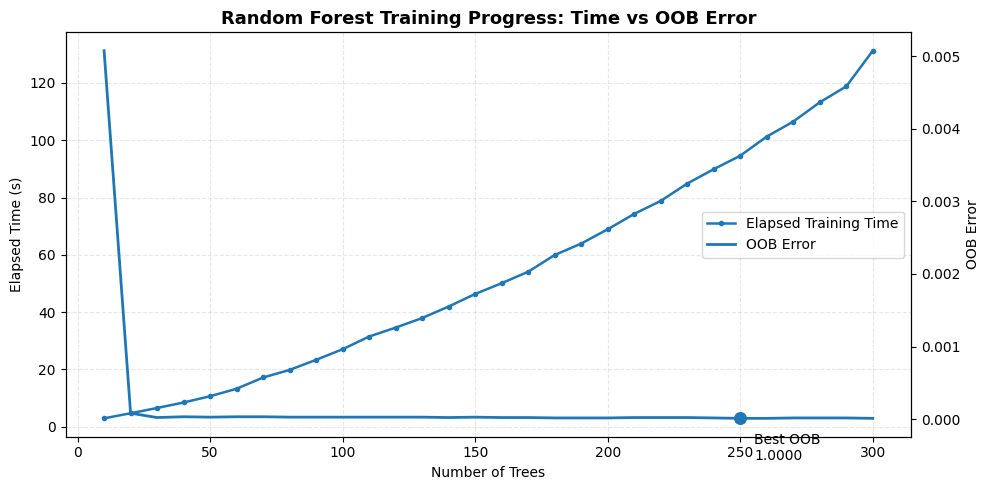

In [60]:
model_rf.fit(
    X_train_fit_smote,
    y_train_fit_smote
)

# cek waktu training
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# RANDOM FOREST TRAINING MONITORING
# ============================================================

# Rentang jumlah trees yang ingin diamati
tree_values = range(10, 301, 10)

# Model khusus untuk monitoring
rf_monitor = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1,
    warm_start=True,
    oob_score=True
)

training_log = []

total_start = time.time()

for n_trees in tree_values:

    # Tambahkan jumlah tree
    rf_monitor.n_estimators = n_trees

    # Waktu untuk penambahan tree pada step ini
    step_start = time.time()

    rf_monitor.fit(
        X_train_fit_smote,
        y_train_fit_smote
    )

    step_time = time.time() - step_start
    total_time = time.time() - total_start

    # OOB score
    oob_score = rf_monitor.oob_score_

    # OOB error
    oob_error = 1 - oob_score

    # Simpan hasil
    training_log.append({
        "n_trees": n_trees,
        "step_time": step_time,
        "elapsed_time": total_time,
        "oob_score": oob_score,
        "oob_error": oob_error
    })


# ============================================================
# DATAFRAME HASIL MONITORING
# ============================================================

df_rf_training = pd.DataFrame(training_log)


# ============================================================
# TRAINING SUMMARY
# ============================================================

total_training_time = df_rf_training["elapsed_time"].iloc[-1]
final_n_trees = df_rf_training["n_trees"].iloc[-1]

# Rata-rata waktu per tree
average_time_per_tree = (
    total_training_time / final_n_trees
)

# OOB terbaik
best_oob_idx = df_rf_training["oob_score"].idxmax()

best_oob_score = df_rf_training.loc[
    best_oob_idx, "oob_score"
]

best_oob_error = df_rf_training.loc[
    best_oob_idx, "oob_error"
]

best_oob_trees = int(
    df_rf_training.loc[
        best_oob_idx, "n_trees"
    ]
)


print("\n=== RANDOM FOREST TRAINING SUMMARY ===")
print(f"Total waktu training : {total_training_time:.2f} detik")
print(f"Jumlah trees         : {final_n_trees}")
print(f"Rata-rata waktu/tree : {average_time_per_tree:.4f} detik")
print(f"Best OOB Score       : {best_oob_score:.4f}")
print(f"Best OOB Error       : {best_oob_error:.4f}")
print(f"Trees pada best OOB  : {best_oob_trees}")


# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 5))

# ------------------------------------------------------------
# Sumbu kiri: elapsed training time
# ------------------------------------------------------------

line1, = ax1.plot(
    df_rf_training["n_trees"],
    df_rf_training["elapsed_time"],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Elapsed Training Time"
)

ax1.set_xlabel("Number of Trees")
ax1.set_ylabel("Elapsed Time (s)")

ax1.grid(
    alpha=0.3,
    linestyle="--"
)


# ------------------------------------------------------------
# Sumbu kanan: OOB Error
# ------------------------------------------------------------

ax2 = ax1.twinx()

line2, = ax2.plot(
    df_rf_training["n_trees"],
    df_rf_training["oob_error"],
    linewidth=2,
    label="OOB Error"
)

ax2.set_ylabel("OOB Error")


# ------------------------------------------------------------
# Tandai best OOB
# ------------------------------------------------------------

best_x = df_rf_training.loc[
    best_oob_idx,
    "n_trees"
]

best_y = df_rf_training.loc[
    best_oob_idx,
    "oob_error"
]

ax2.scatter(
    best_x,
    best_y,
    s=70,
    zorder=5
)

ax2.annotate(
    f"Best OOB\n{best_oob_score:.4f}",
    xy=(best_x, best_y),
    xytext=(10, -30),
    textcoords="offset points"
)


# ------------------------------------------------------------
# Gabungkan legend
# ------------------------------------------------------------

lines = [line1, line2]

labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="center right"
)


# ------------------------------------------------------------
# Judul
# ------------------------------------------------------------

plt.title(
    "Random Forest Training Progress: Time vs OOB Error",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# d. Mengecek Jumlah Feature yang Digunakan

In [61]:
print("Jumlah feature :", X_train_fit_smote.shape[1])
print("Daftar feature :")
print(X_train_fit_smote.columns.tolist())

Jumlah feature : 19
Daftar feature :
['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Pkts/s', 'Bwd Pkts/s', 'SYN Flag Cnt', 'ACK Flag Cnt', 'RST Flag Cnt', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Seg Size Min']


## 8. Evaluasi Model Random Forest

# a. Melakukan Prediksi pada Data Testing

In [62]:
# Melakukan prediksi pada data testing
y_pred = model_rf.predict(X_test)

# Probabilitas kelas SSH-Bruteforce
y_pred_proba = model_rf.predict_proba(X_test)[:, 1]

# b. Menghitung Accuracy, Precision, Recall, dan F1-Score

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL Random Forest ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

=== HASIL EVALUASI MODEL Random Forest ===
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 0.9998
F1-Score  : 0.9998


# c. Menghitung AUC

In [64]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC       : {auc:.4f}")

AUC       : 1.0000


# d. Menampilkan Confusion Matrix

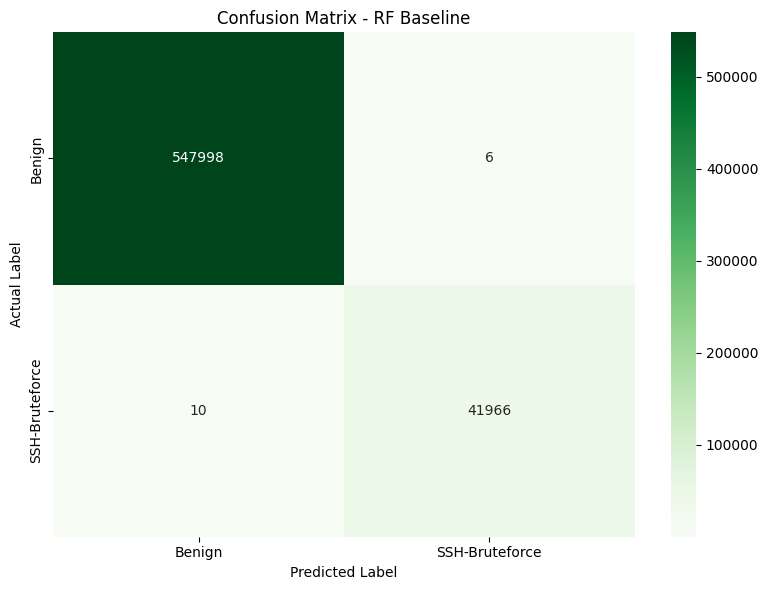

In [65]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix - RF Baseline')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# e. Menampilkan Classification Report

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    548004
SSH-Bruteforce       1.00      1.00      1.00     41976

      accuracy                           1.00    589980
     macro avg       1.00      1.00      1.00    589980
  weighted avg       1.00      1.00      1.00    589980



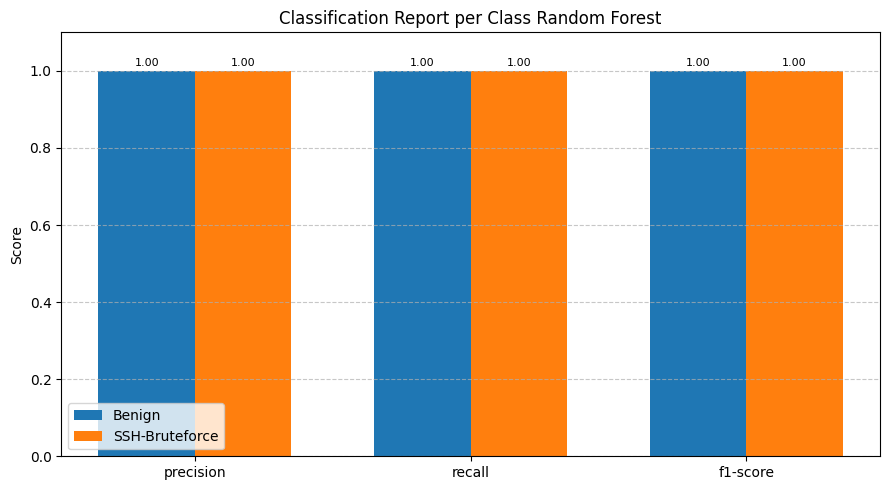

In [66]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Benign', 'SSH-Bruteforce']
    )
)

# bar plot distribusi classification report per class
report = classification_report(
    y_test, y_pred,
    target_names=['Benign', 'SSH-Bruteforce'],
    output_dict=True
)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :3]

metrics = df_report.columns
classes = df_report.index
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, cls in enumerate(classes):
    offset = (i - len(classes)/2 + 0.5) * width
    bars = ax.bar(x + offset, df_report.loc[cls], width, label=cls)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Report per Class Random Forest')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# f. Menampilkan Seluruh Hasil Evaluasi

In [67]:
print("=== RINGKASAN EVALUASI Random Forest ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

=== RINGKASAN EVALUASI Random Forest ===
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 0.9998
F1-Score  : 0.9998
AUC       : 1.0000


## 9. Feature Importance

# a. Mengambil Feature Importance

In [68]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_fit_smote.columns,
    'Importance': model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
18   Fwd Seg Size Min    0.289477
4     TotLen Fwd Pkts    0.129901
16  Init Fwd Win Byts    0.104124
17  Init Bwd Win Byts    0.083745
3        Tot Bwd Pkts    0.068347
2        Tot Fwd Pkts    0.066338
12         Bwd Pkts/s    0.064853
7       Flow IAT Mean    0.043475
1       Flow Duration    0.040000
5     TotLen Bwd Pkts    0.031960
6         Flow Pkts/s    0.028383
11         Fwd Pkts/s    0.026029
9        Fwd IAT Mean    0.008240
10       Bwd IAT Mean    0.004691
8        Flow IAT Std    0.004012
14       ACK Flag Cnt    0.003732
0            Protocol    0.002658
13       SYN Flag Cnt    0.000034
15       RST Flag Cnt    0.000003


# b. Menampilkan Ranking Feature Importance

In [69]:
feature_importance['Rank'] = range(1, len(feature_importance) + 1)

feature_importance = feature_importance[
    ['Rank', 'Feature', 'Importance']
]

print(feature_importance.to_string(index=False))

 Rank           Feature  Importance
    1  Fwd Seg Size Min    0.289477
    2   TotLen Fwd Pkts    0.129901
    3 Init Fwd Win Byts    0.104124
    4 Init Bwd Win Byts    0.083745
    5      Tot Bwd Pkts    0.068347
    6      Tot Fwd Pkts    0.066338
    7        Bwd Pkts/s    0.064853
    8     Flow IAT Mean    0.043475
    9     Flow Duration    0.040000
   10   TotLen Bwd Pkts    0.031960
   11       Flow Pkts/s    0.028383
   12        Fwd Pkts/s    0.026029
   13      Fwd IAT Mean    0.008240
   14      Bwd IAT Mean    0.004691
   15      Flow IAT Std    0.004012
   16      ACK Flag Cnt    0.003732
   17          Protocol    0.002658
   18      SYN Flag Cnt    0.000034
   19      RST Flag Cnt    0.000003


# c. Visualisasi Feature Importance

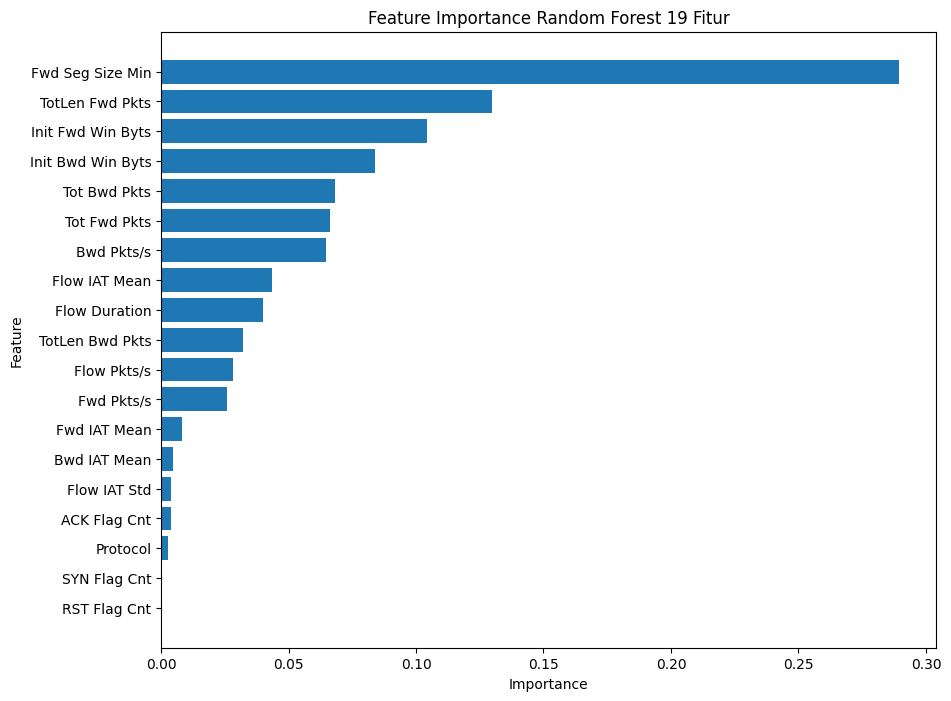

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Random Forest 19 Fitur')

plt.show()

# d. Melihat 10 Fitur Teratas

In [71]:
top10_features = feature_importance.head(10)

print("=== TOP 10 FEATURE IMPORTANCE ===")
print(top10_features.to_string(index=False))

=== TOP 10 FEATURE IMPORTANCE ===
 Rank           Feature  Importance
    1  Fwd Seg Size Min    0.289477
    2   TotLen Fwd Pkts    0.129901
    3 Init Fwd Win Byts    0.104124
    4 Init Bwd Win Byts    0.083745
    5      Tot Bwd Pkts    0.068347
    6      Tot Fwd Pkts    0.066338
    7        Bwd Pkts/s    0.064853
    8     Flow IAT Mean    0.043475
    9     Flow Duration    0.040000
   10   TotLen Bwd Pkts    0.031960


# e. Mengecek Dominasi Fitur

In [72]:
feature_importance['Importance (%)'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

print(
    feature_importance[
        ['Rank', 'Feature', 'Importance', 'Importance (%)']
    ].to_string(index=False)
)

 Rank           Feature  Importance  Importance (%)
    1  Fwd Seg Size Min    0.289477       28.947672
    2   TotLen Fwd Pkts    0.129901       12.990139
    3 Init Fwd Win Byts    0.104124       10.412425
    4 Init Bwd Win Byts    0.083745        8.374461
    5      Tot Bwd Pkts    0.068347        6.834652
    6      Tot Fwd Pkts    0.066338        6.633829
    7        Bwd Pkts/s    0.064853        6.485317
    8     Flow IAT Mean    0.043475        4.347519
    9     Flow Duration    0.040000        3.999952
   10   TotLen Bwd Pkts    0.031960        3.195969
   11       Flow Pkts/s    0.028383        2.838255
   12        Fwd Pkts/s    0.026029        2.602885
   13      Fwd IAT Mean    0.008240        0.824016
   14      Bwd IAT Mean    0.004691        0.469076
   15      Flow IAT Std    0.004012        0.401243
   16      ACK Flag Cnt    0.003732        0.373215
   17          Protocol    0.002658        0.265767
   18      SYN Flag Cnt    0.000034        0.003356
   19      R

## 10. Eksperimen Random Forest dengan 18 Fitur

# a. Membuat daftar 18 fitur

In [ ]:
selected_features_18 = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'RST Flag Cnt',
    'Init Fwd Win Byts',
    'Fwd Seg Size Min'
]

print("Jumlah fitur:", len(selected_features_18))
print(selected_features_18)

# b. Membuat data 18 fitur

In [ ]:
X_train_18 = X_train[selected_features_18]
X_valid_18 = X_valid[selected_features_18]
X_test_18 = X_test[selected_features_18]

print("X_train_18 :", X_train_18.shape)
print("X_valid_18 :", X_valid_18.shape)
print("X_test_18  :", X_test_18.shape)

# c. Membuat ulang Train Fit dan Validation

In [ ]:
X_train_fit_18, X_valid_18, y_train_fit_18, y_valid_18 = train_test_split(
    X_train_18,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit_18.shape)
print("Validation:", X_valid_18.shape)

# d. Melakukan SMOTE pada Train Fit

In [ ]:
smote_18 = SMOTE(random_state=42)

X_train_fit_smote_18, y_train_fit_smote_18 = smote_18.fit_resample(
    X_train_fit_18,
    y_train_fit_18
)

print("Sebelum SMOTE :", X_train_fit_18.shape)
print("Setelah SMOTE :", X_train_fit_smote_18.shape)

# e. Mengecek distribusi hasil SMOTE

In [ ]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote_18.value_counts())

print("\nDistribusi Validation:")
print(y_valid_18.value_counts())

# f. Membuat Model Random Forest 18 Fitur

In [ ]:
model_rf_18 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# g. Training Random Forest 18 Fitur

In [ ]:
model_rf_18.fit(
    X_train_fit_smote_18,
    y_train_fit_smote_18
)

# h. Evaluasi pada Testing

In [ ]:
y_pred_18 = model_rf_18.predict(X_test_18)
y_pred_proba_18 = model_rf_18.predict_proba(X_test_18)[:, 1]

# j. Menghitung Metrik

In [ ]:
accuracy_18 = accuracy_score(y_test, y_pred_18)
precision_18 = precision_score(y_test, y_pred_18)
recall_18 = recall_score(y_test, y_pred_18)
f1_18 = f1_score(y_test, y_pred_18)
auc_18 = roc_auc_score(y_test, y_pred_proba_18)

print("=== HASIL EVALUASI Random Forest 18 FITUR ===")
print(f"Accuracy  : {accuracy_18:.4f}")
print(f"Precision : {precision_18:.4f}")
print(f"Recall    : {recall_18:.4f}")
print(f"F1-Score  : {f1_18:.4f}")
print(f"AUC       : {auc_18:.4f}")

# k. Confusion Matrix

In [ ]:
cm_18 = confusion_matrix(y_test, y_pred_18)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_18, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — Random Forest 18 Fitur')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# l. Membandingkan 19 dan 18 Fitur

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Random Forest 19 Fitur', 'Random Forest 18 Fitur'],
    'Accuracy': [accuracy, accuracy_18],
    'Precision': [precision, precision_18],
    'Recall': [recall, recall_18],
    'F1-Score': [f1, f1_18],
    'AUC': [auc, auc_18]
})

print(comparison.to_string(index=False))

## 11. Feature Importance Random Forest 18 Fitur

# a. Mengambil Feature Importance

In [ ]:
feature_importance_18 = pd.DataFrame({
    'Feature': X_train_fit_smote_18.columns,
    'Importance': model_rf_18.feature_importances_
})

feature_importance_18 = feature_importance_18.sort_values(
    by='Importance',
    ascending=False
)

# b. Menampilkan Ranking

In [ ]:
feature_importance_18['Rank'] = range(
    1,
    len(feature_importance_18) + 1
)

feature_importance_18 = feature_importance_18[
    ['Rank', 'Feature', 'Importance']
]

print("=== FEATURE IMPORTANCE 18 FITUR ===")
print(feature_importance_18.to_string(index=False))

# c. Menghitung Persentase Importance

In [ ]:
feature_importance_18['Importance (%)'] = (
    feature_importance_18['Importance'] /
    feature_importance_18['Importance'].sum()
) * 100

print(
    feature_importance_18[
        ['Rank', 'Feature', 'Importance', 'Importance (%)']
    ].to_string(index=False)
)

# d. Visualisasi

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_18['Feature'],
    feature_importance_18['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Random Forest - 18 Fitur')

plt.show()

print("=== TOP 10 FEATURE IMPORTANCE 18 FITUR ===")

print(
    feature_importance_18.head(10).to_string(index=False)
)

## 12. Eksperimen Random Forest dengan 17 Fitur

# a. Membuat daftar 17 fitur

In [ ]:
selected_features_17 = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'RST Flag Cnt',
    'Fwd Seg Size Min'
]

print("Jumlah fitur:", len(selected_features_17))
print(selected_features_17)

# b. Membuat dataset 17 fitur

In [ ]:
X_train_17 = X_train[selected_features_17]
X_test_17 = X_test[selected_features_17]

print("X_train_17 :", X_train_17.shape)
print("X_test_17  :", X_test_17.shape)

# c. Membagi Training menjadi Train Fit dan Validation

In [ ]:
X_train_fit_17, X_valid_17, y_train_fit_17, y_valid_17 = train_test_split(
    X_train_17,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit_17.shape)
print("Validation:", X_valid_17.shape)

# d. Melakukan SMOTE

In [ ]:
smote_17 = SMOTE(random_state=42)

X_train_fit_smote_17, y_train_fit_smote_17 = smote_17.fit_resample(
    X_train_fit_17,
    y_train_fit_17
)

print("Sebelum SMOTE :", X_train_fit_17.shape)
print("Setelah SMOTE :", X_train_fit_smote_17.shape)

# e. Mengecek Distribusi

In [ ]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote_17.value_counts())

print("\nDistribusi Validation:")
print(y_valid_17.value_counts())

# f. Membuat Model Random Forest 17 Fitur

In [ ]:
model_rf_17 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# g. Training Random Forest

In [ ]:
model_rf_17.fit(
    X_train_fit_smote_17,
    y_train_fit_smote_17
)

# h. Prediksi Testing

In [ ]:
y_pred_17 = model_rf_17.predict(X_test_17)
y_pred_proba_17 = model_rf_17.predict_proba(X_test_17)[:, 1]

# i. Evaluasi Model

In [ ]:
accuracy_17 = accuracy_score(y_test, y_pred_17)
precision_17 = precision_score(y_test, y_pred_17)
recall_17 = recall_score(y_test, y_pred_17)
f1_17 = f1_score(y_test, y_pred_17)
auc_17 = roc_auc_score(y_test, y_pred_proba_17)

print("=== HASIL EVALUASI Random Forest 17 FITUR ===")
print(f"Accuracy  : {accuracy_17:.6f}")
print(f"Precision : {precision_17:.6f}")
print(f"Recall    : {recall_17:.6f}")
print(f"F1-Score  : {f1_17:.6f}")
print(f"AUC       : {auc_17:.6f}")

# j. Confusion Matrix

In [ ]:
cm_17 = confusion_matrix(y_test, y_pred_17)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_17, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — 17 Fitur')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# k. Membandingkan 19, 18, dan 17 Fitur

In [ ]:
comparison_features = pd.DataFrame({
    'Model': [
        'Random Forest 19 Fitur',
        'Random Forest 18 Fitur',
        'Random Forest 17 Fitur'
    ],
    'Accuracy': [
        accuracy,
        accuracy_18,
        accuracy_17
    ],
    'Precision': [
        precision,
        precision_18,
        precision_17
    ],
    'Recall': [
        recall,
        recall_18,
        recall_17
    ],
    'F1-Score': [
        f1,
        f1_18,
        f1_17
    ],
    'AUC': [
        auc,
        auc_18,
        auc_17
    ]
})

print(comparison_features.to_string(index=False))

# l. Feature Importance 17 Fitur

In [ ]:
feature_importance_17 = pd.DataFrame({
    'Feature': X_train_fit_smote_17.columns,
    'Importance': model_rf_17.feature_importances_
})

feature_importance_17 = feature_importance_17.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_17['Importance (%)'] = (
    feature_importance_17['Importance'] /
    feature_importance_17['Importance'].sum()
) * 100

print(
    feature_importance_17.to_string(index=False)
)

## 13. Eksperimen Random Forest dengan 16 Fitur

# a. Membuat daftar 16 fitur

In [ ]:
selected_features_16 = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'RST Flag Cnt'
]

print("Jumlah fitur:", len(selected_features_16))
print(selected_features_16)

# b. Membuat dataset 16 fitur

In [ ]:
X_train_16 = X_train[selected_features_16]
X_test_16 = X_test[selected_features_16]

print("X_train_16 :", X_train_16.shape)
print("X_test_16  :", X_test_16.shape)

# c. Membagi Training dan Validation

In [ ]:
X_train_fit_16, X_valid_16, y_train_fit_16, y_valid_16 = train_test_split(
    X_train_16,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit_16.shape)
print("Validation:", X_valid_16.shape)

# d. Melakukan SMOTE

In [ ]:
smote_16 = SMOTE(random_state=42)

X_train_fit_smote_16, y_train_fit_smote_16 = smote_16.fit_resample(
    X_train_fit_16,
    y_train_fit_16
)

print("Sebelum SMOTE :", X_train_fit_16.shape)
print("Setelah SMOTE :", X_train_fit_smote_16.shape)

# e. Mengecek Distribusi

In [ ]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote_16.value_counts())

print("\nDistribusi Validation:")
print(y_valid_16.value_counts())

# f. Membuat Model Random Forest 16 Fitur

In [ ]:
model_rf_16 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# g. Training Random Forest

In [ ]:
model_rf_16.fit(
    X_train_fit_smote_16,
    y_train_fit_smote_16
)

# h. Prediksi Testing

In [ ]:
y_pred_16 = model_rf_16.predict(X_test_16)
y_pred_proba_16 = model_rf_16.predict_proba(X_test_16)[:, 1]

# i. Evaluasi Model

In [ ]:
accuracy_16 = accuracy_score(y_test, y_pred_16)
precision_16 = precision_score(y_test, y_pred_16)
recall_16 = recall_score(y_test, y_pred_16)
f1_16 = f1_score(y_test, y_pred_16)
auc_16 = roc_auc_score(y_test, y_pred_proba_16)

print("=== HASIL EVALUASI Random Forest 16 FITUR ===")
print(f"Accuracy  : {accuracy_16:.6f}")
print(f"Precision : {precision_16:.6f}")
print(f"Recall    : {recall_16:.6f}")
print(f"F1-Score  : {f1_16:.6f}")
print(f"AUC       : {auc_16:.6f}")

# j. Confusion Matrix

In [ ]:
cm_16 = confusion_matrix(y_test, y_pred_16)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_16, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — 16 Fitur')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# k. Membandingkan 19–16 Fitur

In [ ]:
comparison_features = pd.DataFrame({
    'Model': [
        'Random Forest 19 Fitur',
        'Random Forest 18 Fitur',
        'Random Forest 17 Fitur',
        'Random Forest 16 Fitur'
    ],
    'Accuracy': [
        accuracy,
        accuracy_18,
        accuracy_17,
        accuracy_16
    ],
    'Precision': [
        precision,
        precision_18,
        precision_17,
        precision_16
    ],
    'Recall': [
        recall,
        recall_18,
        recall_17,
        recall_16
    ],
    'F1-Score': [
        f1,
        f1_18,
        f1_17,
        f1_16
    ],
    'AUC': [
        auc,
        auc_18,
        auc_17,
        auc_16
    ]
})

print(comparison_features.to_string(index=False))

# k. Feature Importance 16 Fitur

In [ ]:
feature_importance_16 = pd.DataFrame({
    'Feature': X_train_fit_smote_16.columns,
    'Importance': model_rf_16.feature_importances_
})

feature_importance_16 = feature_importance_16.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_16['Importance (%)'] = (
    feature_importance_16['Importance'] /
    feature_importance_16['Importance'].sum()
) * 100

print(
    feature_importance_16.to_string(index=False)
)

## 14. Eksperimen Random Forest dengan 15 Fitur

# a. Membuat daftar 15 fitur

In [ ]:
selected_features_15 = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'RST Flag Cnt'
]

print("Jumlah fitur:", len(selected_features_15))
print(selected_features_15)

# b. Membuat dataset 15 fitur

In [ ]:
X_train_15 = X_train[selected_features_15]
X_test_15 = X_test[selected_features_15]

print("X_train_15 :", X_train_15.shape)
print("X_test_15  :", X_test_15.shape)

# c. Membagi Training dan Validation

In [ ]:
X_train_fit_15, X_valid_15, y_train_fit_15, y_valid_15 = train_test_split(
    X_train_15,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit_15.shape)
print("Validation:", X_valid_15.shape)

# d. Melakukan SMOTE

In [ ]:
smote_15 = SMOTE(random_state=42)

X_train_fit_smote_15, y_train_fit_smote_15 = smote_15.fit_resample(
    X_train_fit_15,
    y_train_fit_15
)

print("Sebelum SMOTE :", X_train_fit_15.shape)
print("Setelah SMOTE :", X_train_fit_smote_15.shape)

# e. Mengecek Distribusi

In [ ]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote_15.value_counts())

print("\nDistribusi Validation:")
print(y_valid_15.value_counts())

# f. Membuat Model Random Forest 15 Fitur

In [ ]:
model_rf_15 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# g. Training Random Forest

In [ ]:
model_rf_15.fit(
    X_train_fit_smote_15,
    y_train_fit_smote_15
)

# h. Prediksi Testing

In [ ]:
y_pred_15 = model_rf_15.predict(X_test_15)
y_pred_proba_15 = model_rf_15.predict_proba(X_test_15)[:, 1]

# i. Evaluasi Model

In [ ]:
accuracy_15 = accuracy_score(y_test, y_pred_15)
precision_15 = precision_score(y_test, y_pred_15)
recall_15 = recall_score(y_test, y_pred_15)
f1_15 = f1_score(y_test, y_pred_15)
auc_15 = roc_auc_score(y_test, y_pred_proba_15)

print("=== HASIL EVALUASI Random Forest 15 FITUR ===")
print(f"Accuracy  : {accuracy_15:.6f}")
print(f"Precision : {precision_15:.6f}")
print(f"Recall    : {recall_15:.6f}")
print(f"F1-Score  : {f1_15:.6f}")
print(f"AUC       : {auc_15:.6f}")

# j. Confusion Matrix

In [ ]:
cm_15 = confusion_matrix(y_test, y_pred_15)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_15, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — 15 Fitur')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# k. Perbandingan 19–15 Fitur

In [ ]:
comparison_features = pd.DataFrame({
    'Model': [
        'Random Forest 19 Fitur',
        'Random Forest 18 Fitur',
        'Random Forest 17 Fitur',
        'Random Forest 16 Fitur',
        'Random Forest 15 Fitur'
    ],
    'Accuracy': [
        accuracy,
        accuracy_18,
        accuracy_17,
        accuracy_16,
        accuracy_15
    ],
    'Precision': [
        precision,
        precision_18,
        precision_17,
        precision_16,
        precision_15
    ],
    'Recall': [
        recall,
        recall_18,
        recall_17,
        recall_16,
        recall_15
    ],
    'F1-Score': [
        f1,
        f1_18,
        f1_17,
        f1_16,
        f1_15
    ],
    'AUC': [
        auc,
        auc_18,
        auc_17,
        auc_16,
        auc_15
    ]
})

print(comparison_features.to_string(index=False))

# l. Feature Importance 15 Fitur

In [ ]:
feature_importance_15 = pd.DataFrame({
    'Feature': X_train_fit_smote_15.columns,
    'Importance': model_rf_15.feature_importances_
})

feature_importance_15 = feature_importance_15.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_15['Importance (%)'] = (
    feature_importance_15['Importance'] /
    feature_importance_15['Importance'].sum()
) * 100

print(
    feature_importance_15.to_string(index=False)
)

# 15. Tuning Parameter Menggunakan Optuna

# a. Import

In [73]:
!pip install optuna -q
import optuna
from optuna.samplers import TPESampler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.2 MB/s eta 0:00:00


# b. Buat objektif

In [74]:
def objective_rf_19(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 200, 1000, step=100
        ),

        'max_depth': trial.suggest_int(
            'max_depth', 5, 30
        ),

        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 20
        ),

        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 1, 10
        ),

        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', None]
        ),

        'criterion': trial.suggest_categorical(
            'criterion',
            ['gini', 'entropy', 'log_loss']
        ),

        'bootstrap': trial.suggest_categorical(
            'bootstrap',
            [True, False]
        ),

        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    model.fit(
        X_train_fit_smote,
        y_train_fit_smote
    )

    y_pred_valid = model.predict(X_valid)

    f1 = f1_score(
        y_valid,
        y_pred_valid
    )

    return f1

# c. Jalankan dengan 30 trial



In [76]:
study_rf_19 = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study_rf_19.optimize(
    objective_rf_19,
    n_trials=30
)

[I 2026-10-06 13:11:50,772] A new study created in memory with name: no-name-c1e63018-1527-4153-8095-28cd6cbe1e12
[I 2026-10-06 13:14:59,040] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 500, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini', 'bootstrap': False}. Best is trial 0 with value: 1.0.
[I 2026-10-06 13:18:48,385] Trial 1 finished with value: 0.9999668203988188 and parameters: {'n_estimators': 900, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy', 'bootstrap': False}. Best is trial 0 with value: 1.0.
[I 2026-10-06 13:23:37,655] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 600, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': None, 'criterion': 'log_loss', 'bootstrap': True}. Best is trial 0 with value: 1.0.
[I 2026-10-06 13:25:10,800] Trial 3 finished with value: 1.0 and parameters: {'n

# d. Tampilkan hasil parameter tuning

In [77]:
print("HASIL OPTUNA - RANDOM FOREST 19 FITUR")
print(f"Best F1-Score : {study_rf_19.best_value:.6f}")

print("\nBest Parameters:")
for param, value in study_rf_19.best_params.items():
    print(f"{param}: {value}")

HASIL OPTUNA - RANDOM FOREST 19 FITUR
Best F1-Score : 1.000000

Best Parameters:
n_estimators: 500
max_depth: 29
min_samples_split: 15
min_samples_leaf: 6
max_features: sqrt
criterion: gini
bootstrap: False


# 16. Training RF Parameter Tuning

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(



=== RANDOM FOREST TRAINING SUMMARY ===
Total waktu training : 121.65 detik
Jumlah trees         : 300
Rata-rata waktu/tree : 0.4055 detik
Best OOB Score       : 1.0000
Best OOB Error       : 0.0000
Trees pada best OOB  : 250


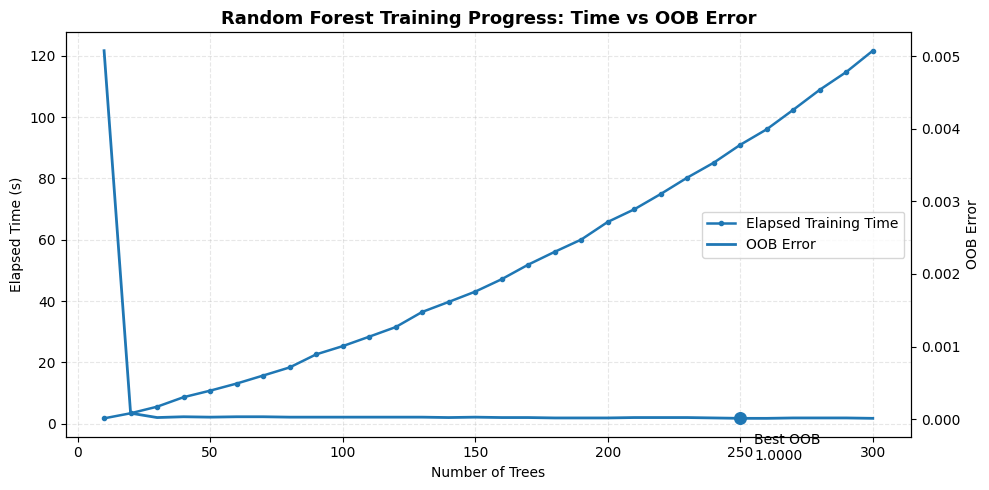

In [78]:
best_params_rf_19 = study_rf_19.best_params

model_rf_19_optuna = RandomForestClassifier(
    **best_params_rf_19,
    random_state=42,
    n_jobs=-1
)

model_rf_19_optuna.fit(
    X_train_fit_smote,
    y_train_fit_smote
)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# RANDOM FOREST TRAINING MONITORING
# ============================================================

# Rentang jumlah trees yang ingin diamati
tree_values = range(10, 301, 10)

# Model khusus untuk monitoring
rf_monitor = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1,
    warm_start=True,
    oob_score=True
)

training_log = []

total_start = time.time()

for n_trees in tree_values:

    # Tambahkan jumlah tree
    rf_monitor.n_estimators = n_trees

    # Waktu untuk penambahan tree pada step ini
    step_start = time.time()

    rf_monitor.fit(
        X_train_fit_smote,
        y_train_fit_smote
    )

    step_time = time.time() - step_start
    total_time = time.time() - total_start

    # OOB score
    oob_score = rf_monitor.oob_score_

    # OOB error
    oob_error = 1 - oob_score

    # Simpan hasil
    training_log.append({
        "n_trees": n_trees,
        "step_time": step_time,
        "elapsed_time": total_time,
        "oob_score": oob_score,
        "oob_error": oob_error
    })


# ============================================================
# DATAFRAME HASIL MONITORING
# ============================================================

df_rf_training = pd.DataFrame(training_log)


# ============================================================
# TRAINING SUMMARY
# ============================================================

total_training_time = df_rf_training["elapsed_time"].iloc[-1]
final_n_trees = df_rf_training["n_trees"].iloc[-1]

# Rata-rata waktu per tree
average_time_per_tree = (
    total_training_time / final_n_trees
)

# OOB terbaik
best_oob_idx = df_rf_training["oob_score"].idxmax()

best_oob_score = df_rf_training.loc[
    best_oob_idx, "oob_score"
]

best_oob_error = df_rf_training.loc[
    best_oob_idx, "oob_error"
]

best_oob_trees = int(
    df_rf_training.loc[
        best_oob_idx, "n_trees"
    ]
)


print("\n=== RANDOM FOREST TRAINING SUMMARY ===")
print(f"Total waktu training : {total_training_time:.2f} detik")
print(f"Jumlah trees         : {final_n_trees}")
print(f"Rata-rata waktu/tree : {average_time_per_tree:.4f} detik")
print(f"Best OOB Score       : {best_oob_score:.4f}")
print(f"Best OOB Error       : {best_oob_error:.4f}")
print(f"Trees pada best OOB  : {best_oob_trees}")


# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 5))

# ------------------------------------------------------------
# Sumbu kiri: elapsed training time
# ------------------------------------------------------------

line1, = ax1.plot(
    df_rf_training["n_trees"],
    df_rf_training["elapsed_time"],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Elapsed Training Time"
)

ax1.set_xlabel("Number of Trees")
ax1.set_ylabel("Elapsed Time (s)")

ax1.grid(
    alpha=0.3,
    linestyle="--"
)


# ------------------------------------------------------------
# Sumbu kanan: OOB Error
# ------------------------------------------------------------

ax2 = ax1.twinx()

line2, = ax2.plot(
    df_rf_training["n_trees"],
    df_rf_training["oob_error"],
    linewidth=2,
    label="OOB Error"
)

ax2.set_ylabel("OOB Error")


# ------------------------------------------------------------
# Tandai best OOB
# ------------------------------------------------------------

best_x = df_rf_training.loc[
    best_oob_idx,
    "n_trees"
]

best_y = df_rf_training.loc[
    best_oob_idx,
    "oob_error"
]

ax2.scatter(
    best_x,
    best_y,
    s=70,
    zorder=5
)

ax2.annotate(
    f"Best OOB\n{best_oob_score:.4f}",
    xy=(best_x, best_y),
    xytext=(10, -30),
    textcoords="offset points"
)


# ------------------------------------------------------------
# Gabungkan legend
# ------------------------------------------------------------

lines = [line1, line2]

labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="center right"
)


# ------------------------------------------------------------
# Judul
# ------------------------------------------------------------

plt.title(
    "Random Forest Training Progress: Time vs OOB Error",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 17. Evaluasi RF Parameter Tuning

a. Accuracy, precision, recall, f1 score, dan auc score

In [79]:
y_pred_19_optuna = model_rf_19_optuna.predict(X_test)

y_pred_proba_19_optuna = (
    model_rf_19_optuna.predict_proba(X_test)[:, 1]
)

accuracy_19_optuna = accuracy_score(
    y_test,
    y_pred_19_optuna
)

precision_19_optuna = precision_score(
    y_test,
    y_pred_19_optuna
)

recall_19_optuna = recall_score(
    y_test,
    y_pred_19_optuna
)

f1_19_optuna = f1_score(
    y_test,
    y_pred_19_optuna
)

auc_19_optuna = roc_auc_score(
    y_test,
    y_pred_proba_19_optuna
)

In [80]:
print("HASIL RANDOM FOREST 19 FITUR + OPTUNA")
print(f"Accuracy  : {accuracy_19_optuna:.6f}")
print(f"Precision : {precision_19_optuna:.6f}")
print(f"Recall    : {recall_19_optuna:.6f}")
print(f"F1-Score  : {f1_19_optuna:.6f}")
print(f"AUC       : {auc_19_optuna:.6f}")

HASIL RANDOM FOREST 19 FITUR + OPTUNA
Accuracy  : 0.999971
Precision : 0.999881
Recall    : 0.999714
F1-Score  : 0.999797
AUC       : 1.000000


b. Confusion matrix

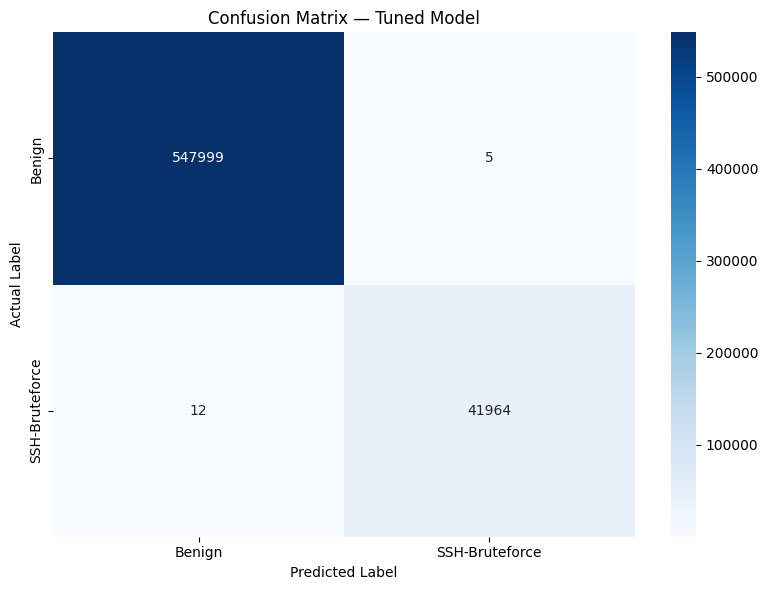

In [81]:
cm_19_optuna = confusion_matrix(y_test, y_pred_19_optuna)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_19_optuna, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — Tuned Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

c. classification report

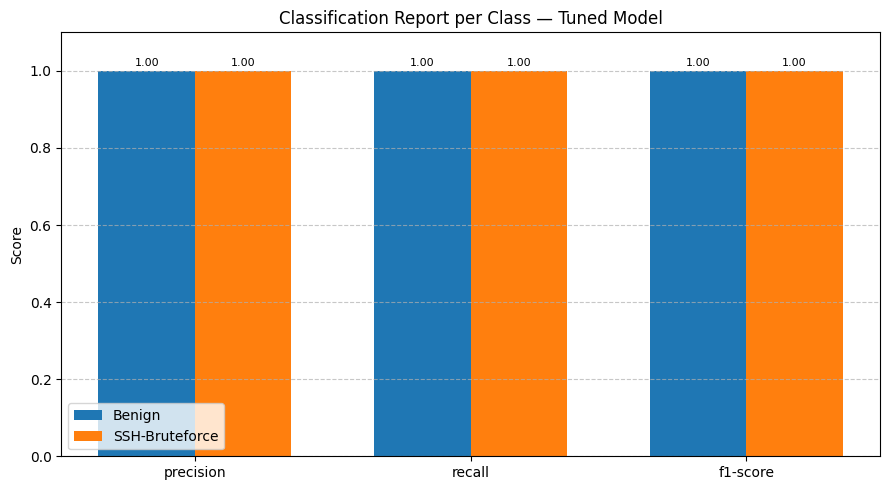

In [82]:
report = classification_report(
    y_test, y_pred_19_optuna,
    target_names=['Benign', 'SSH-Bruteforce'],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose().iloc[:-3, :3]

metrics = df_report.columns
classes = df_report.index
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

for i, cls in enumerate(classes):
    offset = (i - len(classes)/2 + 0.5) * width
    bars = ax.bar(
        x + offset,
        df_report.loc[cls],
        width,
        label=cls
    )
    ax.bar_label(
        bars,
        fmt='%.2f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Report per Class — Tuned Model')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


d. Ringkasan evaluasi model tuned

In [83]:
print("=== RINGKASAN EVALUASI MODEL TUNED (19 FITUR) ===")
print(f"Accuracy  : {accuracy_19_optuna:.4f}")
print(f"Precision : {precision_19_optuna:.4f}")
print(f"Recall    : {recall_19_optuna:.4f}")
print(f"F1-Score  : {f1_19_optuna:.4f}")
print(f"AUC       : {auc_19_optuna:.4f}")

=== RINGKASAN EVALUASI MODEL TUNED (19 FITUR) ===
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 0.9997
F1-Score  : 0.9998
AUC       : 1.0000


# 18. Analisis Feature Importance Model Tuned

a. Mengambil feature importance

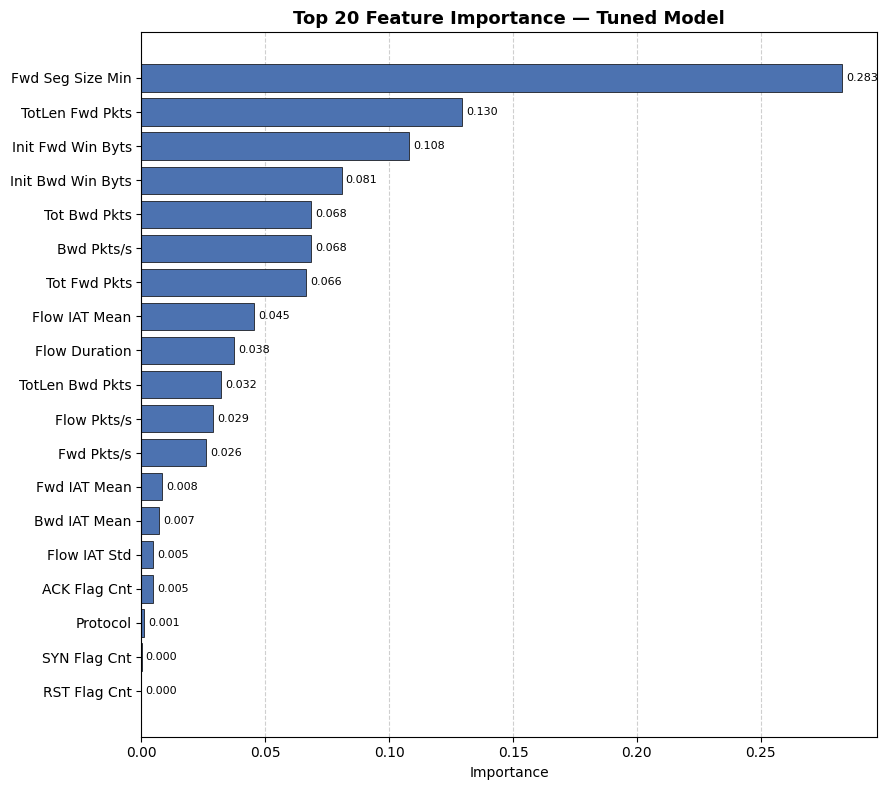

In [84]:
feature_importance = pd.DataFrame({
    'Feature': X_train_fit_smote.columns,
    'Importance': model_rf_19_optuna.feature_importances_
}).sort_values('Importance',ascending=False).reset_index(drop=True)

top_n = 20
df_top = feature_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 8))

bars = plt.barh(
    df_top['Feature'],
    df_top['Importance'],
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.5
)

plt.bar_label(
    bars,
    fmt='%.3f',
    padding=3,
    fontsize=8
)

plt.xlabel('Importance')
plt.title(
    f'Top {top_n} Feature Importance — Tuned Model',
    fontsize=13,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)

plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

b. Menampilkan top 10 feature

In [85]:
top10_features = feature_importance.head(10)

print("=== TOP 10 FEATURE IMPORTANCE ===")
print(top10_features.to_string(index=False))

=== TOP 10 FEATURE IMPORTANCE ===
          Feature  Importance
 Fwd Seg Size Min    0.282858
  TotLen Fwd Pkts    0.129506
Init Fwd Win Byts    0.108057
Init Bwd Win Byts    0.080752
     Tot Bwd Pkts    0.068435
       Bwd Pkts/s    0.068347
     Tot Fwd Pkts    0.066436
    Flow IAT Mean    0.045395
    Flow Duration    0.037538
  TotLen Bwd Pkts    0.032129


c. hitung persentase kontribusi

In [86]:
feature_importance['Percentage'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

print("=== TOP 10 FEATURE IMPORTANCE (%) ===")
print(
    feature_importance[
        ['Feature', 'Importance', 'Percentage']
    ].head(10).to_string(index=False)
)

=== TOP 10 FEATURE IMPORTANCE (%) ===
          Feature  Importance  Percentage
 Fwd Seg Size Min    0.282858   28.285805
  TotLen Fwd Pkts    0.129506   12.950591
Init Fwd Win Byts    0.108057   10.805744
Init Bwd Win Byts    0.080752    8.075170
     Tot Bwd Pkts    0.068435    6.843483
       Bwd Pkts/s    0.068347    6.834670
     Tot Fwd Pkts    0.066436    6.643600
    Flow IAT Mean    0.045395    4.539518
    Flow Duration    0.037538    3.753783
  TotLen Bwd Pkts    0.032129    3.212886


d. cek dominasi feature

In [87]:
top4_percentage = feature_importance.head(4)['Percentage'].sum()

print(f"Kontribusi 4 fitur teratas : {top4_percentage:.2f}%")
print(f"Kontribusi fitur teratas   : {feature_importance.iloc[0]['Percentage']:.2f}%")

Kontribusi 4 fitur teratas : 60.12%
Kontribusi fitur teratas   : 28.29%


# 19. Simpan model sebagai .pkl

# a. Import pickle

In [88]:
import pickle
import os

# b. Mapping Label

In [89]:
label_encoder = {
    0: "Benign",
    1: "SSH-Bruteforce"
}

with open("label_encoder_19Fitur.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

# c. Fitur yang digunakan

In [91]:
with open("selected_features_19Fitur.pkl", "wb") as file:
    pickle.dump(selected_features, file)

# d. Model hasil Optuna

In [92]:
with open("model_rf_v2_19Fitur.pkl", "wb") as file:
    pickle.dump(model_rf_19_optuna, file)

# e. Tampilkan file yang berhasil dibuat

In [93]:
files_to_check = [
    "label_encoder_19Fitur.pkl",
    "model_rf_v2_19Fitur.pkl",
    "selected_features_19Fitur.pkl"
]

print("=" * 60)
print("FILE MODEL RANDOM FOREST")
print("=" * 60)

for file_name in files_to_check:

    if os.path.exists(file_name):
        file_size = os.path.getsize(file_name) / 1024

        print(
            f"✓ {file_name:<30} "
            f"({file_size:.2f} KB)"
        )

    else:
        print(
            f"✗ {file_name:<30} "
            f"TIDAK DITEMUKAN"
        )

print("=" * 60)

# Load label mapping
with open("label_encoder_19Fitur.pkl", "rb") as file:
    loaded_label_encoder = pickle.load(file)

# Load selected features
with open("selected_features_19Fitur.pkl", "rb") as file:
    loaded_features = pickle.load(file)

# Load model
with open("model_rf_v2_19Fitur.pkl", "rb") as file:
    loaded_rf_model = pickle.load(file)

print("=" * 60)
print("VERIFIKASI FILE")
print("=" * 60)

print("\nLabel Mapping:")
print(loaded_label_encoder)

print("\nJumlah Selected Features:")
print(len(loaded_features))

print("\nSelected Features:")
for i, feature in enumerate(loaded_features, 1):
    print(f"{i}. {feature}")

print("\nModel:")
print(loaded_rf_model)

print("\nJumlah Estimator:")
print(loaded_rf_model.n_estimators)

print("\n✓ Semua file berhasil di-load kembali.")

FILE MODEL RANDOM FOREST
✓ label_encoder_19Fitur.pkl      (0.04 KB)
✓ model_rf_v2_19Fitur.pkl        (2256.49 KB)
✓ selected_features_19Fitur.pkl  (0.31 KB)
VERIFIKASI FILE

Label Mapping:
{0: 'Benign', 1: 'SSH-Bruteforce'}

Jumlah Selected Features:
19

Selected Features:
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. SYN Flag Cnt
15. ACK Flag Cnt
16. RST Flag Cnt
17. Init Fwd Win Byts
18. Init Bwd Win Byts
19. Fwd Seg Size Min

Model:
RandomForestClassifier(bootstrap=False, max_depth=29, min_samples_leaf=6,
                       min_samples_split=15, n_estimators=500, n_jobs=-1,
                       random_state=42)

Jumlah Estimator:
500

✓ Semua file berhasil di-load kembali.


In [94]:
# ============================================================
# 5 DATA BENIGN + 5 DATA SSH-BRUTEFORCE
# TANPA NILAI -1 PADA 19 FITUR
# ============================================================

# Ambil hanya baris yang TIDAK memiliki -1
# pada salah satu dari 19 selected_features
valid_rows = ~df[selected_features].eq(-1).any(axis=1)

# Filter berdasarkan label
df_benign_valid = df[
    valid_rows & (df['Label'] == 'Benign')
].copy()

df_ssh_valid = df[
    valid_rows & (df['Label'] == 'SSH-Bruteforce')
].copy()


# ============================================================
# AMBIL 5 DATA DARI MASING-MASING LABEL
# ============================================================

df_benign_sample = df_benign_valid.sample(
    n=5,
    random_state=42
)

df_ssh_sample = df_ssh_valid.sample(
    n=5,
    random_state=42
)


# Gabungkan kedua kelas
df_sample = pd.concat(
    [
        df_benign_sample,
        df_ssh_sample
    ]
)


# ============================================================
# TAMPILKAN DATA
# ============================================================

columns_to_show = [
    'Label'
] + selected_features

print("=== 5 DATA BENIGN + 5 DATA SSH-BRUTEFORCE ===")
print("=== TANPA NILAI -1 PADA 19 FITUR ===\n")

print(
    df_sample[
        columns_to_show
    ].to_string(index=False)
)

=== 5 DATA BENIGN + 5 DATA SSH-BRUTEFORCE ===
=== TANPA NILAI -1 PADA 19 FITUR ===

         Label  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Flow Pkts/s  Flow IAT Mean  Flow IAT Std  Fwd IAT Mean  Bwd IAT Mean  Fwd Pkts/s  Bwd Pkts/s  SYN Flag Cnt  ACK Flag Cnt  RST Flag Cnt  Init Fwd Win Byts  Init Bwd Win Byts  Fwd Seg Size Min
        Benign         6        3436275            10            10             1341             2754     5.820256   1.808566e+05  2.367482e+05  3.818083e+05  3.713769e+05    2.910128    2.910128             0             0             0               8192              62868                20
        Benign         6         922537             8             8              570             7025    17.343478   6.150247e+04  9.782566e+04  1.317910e+05  9.318114e+04    8.671739    8.671739             0             0             0               8192               1025                20
        Benign         6        22